# Forecasting with PaiNN on `paracetamol_reduced`

Use the locally trained PaiNN checkpoint (`runs/paracetamol_reduced_painn`) and dataset in `data/paracetamol_reduced` to reproduce inference and a short trajectory roll-out.

## Setup
Choose device and set double precision (models were trained in float64).

In [35]:
import torch
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [36]:
# match training precision
torch.set_default_dtype(torch.float64)

Define paths to the dataset and the trained PaiNN checkpoint. Update these if you move the notebook.

In [37]:

from pathlib import Path

# Robustly locate repo root (looks for pyproject.toml or .git while walking up)
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() or (p / '.git').exists():
            return p
    return start

PROJECT_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data' / 'paracetamol_reduced'
CHECKPOINT_PATH = PROJECT_ROOT / 'runs' / 'paracetamol_reduced_painn' / 'checkpoints' / 'best_model_epoch-1470.pt'
CONFIG_PATH = PROJECT_ROOT / 'runs' / 'paracetamol_reduced_painn' / 'config_used.yaml'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'painn_traj.extxyz'
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# atomic number -> model type indices (matches training config)
atom_type_mapper = {1: 0, 6: 1, 7: 2, 8: 3}

print(f'Repo root:        {PROJECT_ROOT}')
print(f'Config found:     {CONFIG_PATH.exists()}')
print(f'Checkpoint found: {CHECKPOINT_PATH.exists()}')
print(f'Data root:        {DATA_ROOT}')


Repo root:        /workspace/trajcast
Config found:     True
Checkpoint found: True
Data root:        /workspace/trajcast/data/paracetamol_reduced


## Load the PaiNN model

In [38]:

from trajcast.model.painn import PaiNNModel

model = PaiNNModel.build_from_yaml(filename=str(CONFIG_PATH))
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# Forecast expects an edge_cutoff attribute; add it for PaiNN if missing
if not hasattr(model, 'edge_cutoff'):
    cutoff_val = float(model.config.get('edge_cutoff', model.config.get('cutoff', 4.0)))
    model.edge_cutoff = torch.tensor(cutoff_val)
model.edge_cutoff


/tmp/ipykernel_458/1215209734.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(CHECKPOINT_PATH, map_location=device)


tensor(4.)

## Load the reduced paracetamol test split
The dataset already lives in `data/paracetamol_reduced`. If the processed file is missing the first run will create it (once) from `test_sub.extxyz`.

In [39]:
from trajcast.data.dataset import AtomicGraphDataset

test_set = AtomicGraphDataset(
    root=str(DATA_ROOT),
    name='paracetamol_test',
    cutoff_radius=4.0,
    files=['test_sub.extxyz'],
    atom_type_mapper=atom_type_mapper,
    rename=True,
)

len(test_set)

200

## Single-step inference
Predict displacements and velocity updates on the held-out test frames.

In [40]:

from torch_geometric.loader import DataLoader
import numpy as np

data_loader = DataLoader(test_set, batch_size=5, shuffle=False)

true_disp = test_set.displacements.numpy()
true_vel = test_set.update_velocities.numpy()

pred_disp, pred_vel = [], []

with torch.no_grad():
    for batch in data_loader:
        batch = batch.to(device)
        out = model(batch)
        preds = out.target.cpu().numpy()
        pred_disp.append(preds[:, :3])
        pred_vel.append(preds[:, 3:])

pred_disp = np.concatenate(pred_disp)
pred_vel = np.concatenate(pred_vel)

rmse_disp = np.sqrt(((true_disp - pred_disp) ** 2).mean())
rmse_vel = np.sqrt(((true_vel - pred_vel) ** 2).mean())

print(f"Displacement RMSE: {rmse_disp:.4f} Angstrom")
print(f"Velocity RMSE:     {rmse_vel:.4f} Angstrom/fs")


Displacement RMSE: 0.0005 Angstrom
Velocity RMSE:     0.0002 Angstrom/fs


Parity plots for a quick visual check.

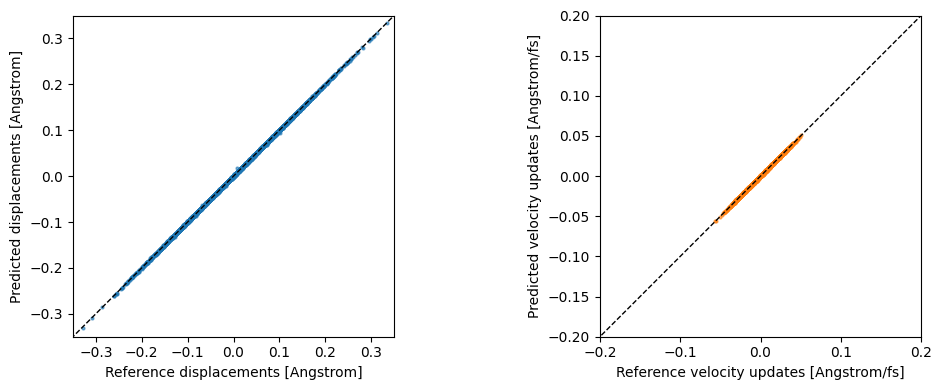

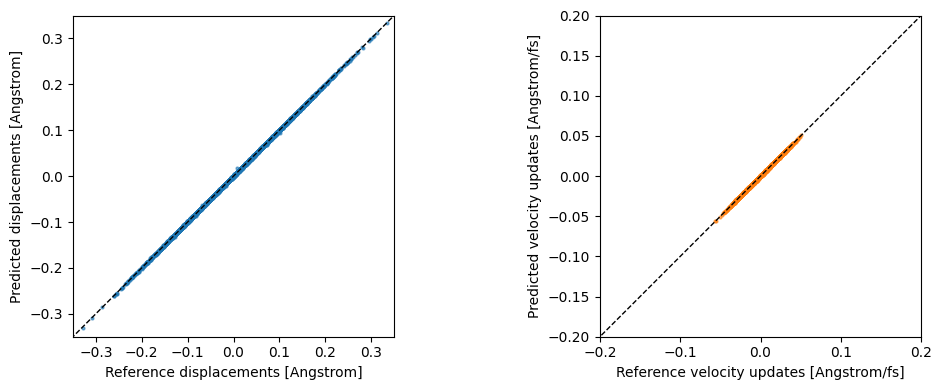

In [41]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(true_disp, pred_disp, s=4, alpha=0.6)
axes[0].plot([-0.4, 0.4], [-0.4, 0.4], 'k--', lw=1)
axes[0].set_xlabel('Reference displacements [Angstrom]')
axes[0].set_ylabel('Predicted displacements [Angstrom]')
axes[0].set_xlim(-0.35, 0.35)
axes[0].set_ylim(-0.35, 0.35)
axes[0].set_aspect('equal')

axes[1].scatter(true_vel, pred_vel, s=4, alpha=0.6, color='tab:orange')
axes[1].plot([-0.25, 0.25], [-0.25, 0.25], 'k--', lw=1)
axes[1].set_xlabel('Reference velocity updates [Angstrom/fs]')
axes[1].set_ylabel('Predicted velocity updates [Angstrom/fs]')
axes[1].set_xlim(-0.2, 0.2)
axes[1].set_ylim(-0.2, 0.2)
axes[1].set_aspect('equal')

fig.tight_layout()
fig


## Roll-out forecast
Take one configuration from the reduced dataset and roll out 100 steps using the trained PaiNN model.

In [42]:
import ase.io

start_frame = ase.io.read(DATA_ROOT / 'test_sub.extxyz', index='-1')
start_frame.center()
# remove supervised targets before forecasting
_ = start_frame.arrays.pop('displacements')
_ = start_frame.arrays.pop('update_velocities')
start_frame

Atoms(symbols='OCHCHCHCHCNCHCHOCH3', pbc=True, cell=[50.0, 50.0, 50.0], velocities=...)

In [45]:

from trajcast.model.forecast import Forecast

protocol = {
    'configuration': start_frame,
    'model': model,  # pass the instantiated model
    'timestep': 7.0,  # fs, matches dataset
    'run': 1000,
    'temperature': 300.0,
    'units': 'real',
    'extra_dof': 6,
    'type_mapper': atom_type_mapper,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'write': {
        'filename': str(OUTPUT_PATH),
        'format': 'extxyz',
        'every': 1,
        'save_velocities': True,
    },
}

forecaster = Forecast(protocol=protocol)
forecaster.generate_trajectory()



00%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 82.26it/s]

Visualize the generated trajectory (optional; requires `nglview`).

In [46]:
import nglview

generated_traj = ase.io.read(protocol['write']['filename'], index=':')
nglview.show_asetraj(generated_traj)

NGLWidget(max_frame=1000)